# INRIA: бинарная сегментация зданий (ConvNeXt-Tiny + FPN)

Обучение на патчах **512×512** из `data/processed_inria/`.

**Перед запуском:**
```bash
python scripts/download_extra_datasets.py --inria
python scripts/prepare_inria_patches.py
python scripts/build_inria_split.py
```

Результат: `models/inria_building_segmenter.pth` → ноутбук **08**.

Визуализация — в конце, секция «inference only».


In [ ]:
import os
from pathlib import Path

_env_path = Path('..').resolve() / '.env'
if _env_path.exists():
    for _line in _env_path.read_text(encoding='utf-8').splitlines():
        _line = _line.strip()
        if not _line or _line.startswith('#') or '=' not in _line:
            continue
        _key, _val = _line.split('=', 1)
        os.environ.setdefault(_key.strip(), _val.strip().strip('"\''))

_hf_token = os.environ.get('HF_TOKEN')
if _hf_token:
    from huggingface_hub import login
    login(token=_hf_token, add_to_git_credential=False)
    print('Hugging Face: авторизация OK')
else:
    print('HF_TOKEN не найден в .env — веса timm скачаются без токена (медленнее)')



In [ ]:
import copy
import json
import os
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import transforms

sys.path.insert(0, str(Path('..').resolve() / 'src'))

import importlib
import model_segmentation as _model_segmentation
importlib.reload(_model_segmentation)

from dataset import InriaSegmentationDataset, load_inria_split
from model_segmentation import (
    build_convnext_segmenter,
    count_trainable_params,
    unfreeze_encoder_stages,
)
from utils import (
    INRIA_PATCH_SIZE,
    INRIA_PATCH_STRIDE,
    INRIA_RAW_DIR,
    INRIA_SEGMENTATION as CFG,
    INRIA_SPLIT_CSV,
    IMAGENET_MEAN,
    IMAGENET_STD,
    MODELS_DIR,
    NUM_WORKERS,
    PLOT_DPI,
    RANDOM_SEED,
    REPORTS_DIR,
    ensure_dirs,
    set_random_seed,
)

BATCH_SIZE = CFG.batch_size
MAX_EPOCHS = CFG.max_epochs
LOSS_EPS = CFG.loss_eps
PATIENCE = CFG.patience
MIN_EPOCHS = CFG.min_epochs
LEARNING_RATE = CFG.learning_rate
WEIGHT_DECAY = CFG.weight_decay
BCE_WEIGHT = CFG.bce_weight
DICE_WEIGHT = CFG.dice_weight
POS_WEIGHT = CFG.pos_weight

LR_CANDIDATES = CFG.lr_candidates
STAGE1_MAX_EPOCHS = CFG.stage1_max_epochs
STAGE1_MIN_EPOCHS = CFG.stage1_min_epochs
STAGE1_PATIENCE = CFG.stage1_patience
STAGE2_STEPS = CFG.stage2_steps
STAGE2_MIN_EPOCHS_FLOOR = CFG.stage2_min_epochs_floor
STAGE2_MAX_EPOCHS_PER_STEP = CFG.stage2_max_epochs_per_step

INFERENCE_PATCH_SIZE = CFG.inference_patch_size
INFERENCE_STRIDE = CFG.inference_stride
N_VAL_EXAMPLES = CFG.n_val_examples
PRED_THRESHOLD = 0.5

LOADER_WORKERS = NUM_WORKERS

ensure_dirs()
set_random_seed()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Устройство:', device)
print(f'batch_size={BATCH_SIZE} | num_workers={LOADER_WORKERS}')
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

STAGE1_CKPT = MODELS_DIR / 'inria_segmenter_stage1_best.pth'
STAGE1_META = MODELS_DIR / 'inria_segmenter_stage1_meta.json'
STAGE2_SUB_CKPT = {i: MODELS_DIR / f'inria_segmenter_stage2_sub{i}_best.pth' for i in (1, 2)}
STAGE2_META = MODELS_DIR / 'inria_segmenter_stage2_meta.json'
SKIP_STAGE1_IF_CHECKPOINT = True
SKIP_STAGE2_IF_CHECKPOINT = True

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = CFG.figure_size


Устройство: cuda
batch_size=24 | num_workers=4
ГПУ: NVIDIA A100-SXM4-40GB


## Загрузка split

In [ ]:
if not INRIA_SPLIT_CSV.exists():
    raise FileNotFoundError(
        f'{INRIA_SPLIT_CSV} не найден. Сначала:\n'
        '  python scripts/prepare_inria_patches.py\n'
        '  python scripts/build_inria_split.py'
    )

split_df = load_inria_split(INRIA_SPLIT_CSV)
print(f'Всего патчей: {len(split_df)}')
print()
print('По split:')
_split_ru = {'train': 'обучение', 'val': 'валидация', 'test': 'тест'}
_split_counts = split_df['split'].value_counts().reindex(['train', 'val', 'test'])
_split_counts.index = [_split_ru[k] for k in _split_counts.index]
print(_split_counts)
print()
print('По split и городу:')
print(split_df.groupby(['split', 'city']).size().to_string())

Всего патчей: 48933

По split:
обучение     31407
валидация    11783
тест          5743
Name: count, dtype: int64

По split и городу:
split  city   
test   tyrol-w     5743
train  austin     11195
       chicago    12053
       kitsap      8159
val    vienna     11783


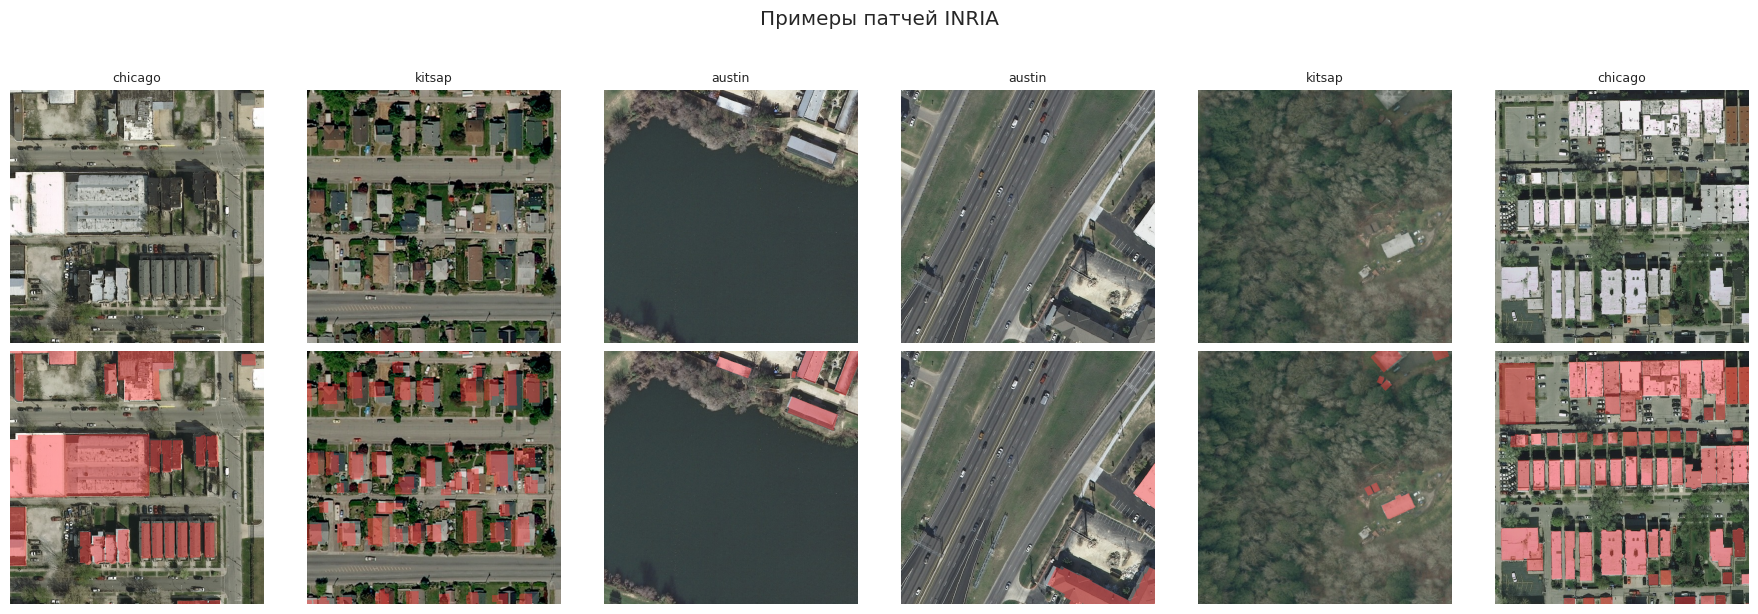

In [ ]:
def overlay_mask_on_image(image: np.ndarray, mask: np.ndarray, color=(255, 60, 60), alpha=0.45) -> np.ndarray:
    """Накладывает бинарную маску на RGB-изображение."""
    out = image.astype(np.float32).copy()
    m = mask.astype(bool)
    tint = np.array(color, dtype=np.float32)
    out[m] = (1 - alpha) * out[m] + alpha * tint
    return np.clip(out, 0, 255).astype(np.uint8)


def show_patch_examples(df: pd.DataFrame, n: int = 6, seed: int = RANDOM_SEED) -> None:
    sample = df.sample(n=min(n, len(df)), random_state=seed)
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    if n == 1:
        axes = np.array([[axes[0]], [axes[1]]])
    for col, (_, row) in enumerate(sample.iterrows()):
        image = np.asarray(Image.open(row['path']).convert('RGB'))
        mask = np.asarray(Image.open(row['mask_path']).convert('L')) >= 128
        axes[0, col].imshow(image)
        axes[0, col].set_title(row.get('city', ''), fontsize=9)
        axes[0, col].axis('off')
        axes[1, col].imshow(overlay_mask_on_image(image, mask))
        axes[1, col].axis('off')
    axes[0, 0].set_ylabel('снимок', fontsize=10)
    axes[1, 0].set_ylabel('маска', fontsize=10)
    fig.suptitle('Примеры патчей INRIA', y=1.02)
    plt.tight_layout()
    plt.show()


show_patch_examples(split_df[split_df['split'] == 'train'], n=6)

## DataLoader

In [ ]:
train_ds = InriaSegmentationDataset(split_df, split='train', augment=True)
val_ds = InriaSegmentationDataset(split_df, split='val', augment=False)
test_ds = InriaSegmentationDataset(split_df, split='test', augment=False)

_loader_kw = dict(
    num_workers=LOADER_WORKERS,
    persistent_workers=LOADER_WORKERS > 0,
    pin_memory=torch.cuda.is_available(),
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, **_loader_kw)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, **_loader_kw)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, **_loader_kw)

print(f'Обучение: {len(train_ds)} | Валидация: {len(val_ds)} | Тест: {len(test_ds)}')

Обучение: 31407 | Валидация: 11783 | Тест: 5743


## Loss, метрики и цикл обучения

- **DiceLoss** — дополняет BCE при дисбалансе фон/здание
- **SegmentationLoss** — взвешенная сумма BCE (`pos_weight`) + Dice
- **pixel_metrics** — IoU, precision, recall, F1 на уровне пикселей
- **train_loop** — ранняя остановка, если val IoU не улучшается `patience` эпох подряд

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1.0) -> None:
        super().__init__()
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits)
        dims = (2, 3)
        intersection = (probs * targets).sum(dim=dims)
        union = probs.sum(dim=dims) + targets.sum(dim=dims)
        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class SegmentationLoss(nn.Module):
    def __init__(
        self,
        pos_weight: float = POS_WEIGHT,
        bce_weight: float = BCE_WEIGHT,
        dice_weight: float = DICE_WEIGHT,
    ) -> None:
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight], dtype=torch.float32)
        )
        self.dice = DiceLoss()

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce = self.bce(logits, targets)
        dice = self.dice(logits, targets)
        return self.bce_weight * bce + self.dice_weight * dice


@torch.no_grad()
def pixel_metrics(logits: torch.Tensor, targets: torch.Tensor, threshold: float = PRED_THRESHOLD) -> dict[str, float]:
    """Бинарные метрики по всем пикселям батча."""
    preds = (torch.sigmoid(logits) >= threshold).float()
    targets = (targets >= 0.5).float()
    tp = (preds * targets).sum().item()
    fp = (preds * (1 - targets)).sum().item()
    fn = ((1 - preds) * targets).sum().item()
    tn = ((1 - preds) * (1 - targets)).sum().item()
    iou = tp / (tp + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    return {
        'iou': iou,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'accuracy': accuracy,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
    }


def run_epoch(loader, model, criterion, optimizer=None, threshold: float = PRED_THRESHOLD):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    metric_sums = {k: 0.0 for k in ['iou', 'precision', 'recall', 'f1', 'accuracy']}
    n_pixels = 0

    with torch.set_grad_enabled(is_train):
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            if is_train:
                optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, masks)

            if is_train:
                loss.backward()
                optimizer.step()

            batch_pixels = images.size(0) * images.size(2) * images.size(3)
            total_loss += loss.item() * images.size(0)
            batch_metrics = pixel_metrics(logits, masks, threshold=threshold)
            for key in metric_sums:
                metric_sums[key] += batch_metrics[key] * batch_pixels
            n_pixels += batch_pixels

    avg_loss = total_loss / len(loader.dataset)
    avg_metrics = {k: v / n_pixels for k, v in metric_sums.items()}
    return avg_loss, avg_metrics


@torch.no_grad()
def evaluate(loader, model, criterion, threshold: float = PRED_THRESHOLD) -> tuple[float, dict[str, float]]:
    loss, metrics = run_epoch(loader, model, criterion, optimizer=None, threshold=threshold)
    return loss, metrics


def _iou_plateau(val_ious: list[float], eps: float = LOSS_EPS, patience: int = PATIENCE) -> bool:
    if len(val_ious) < patience + 1:
        return False
    recent = val_ious[-patience:]
    return all(abs(recent[i] - recent[i - 1]) < eps for i in range(1, len(recent)))


def train_loop(
    model,
    train_loader,
    val_loader,
    lr,
    max_epochs=MAX_EPOCHS,
    min_epochs=MIN_EPOCHS,
    loss_eps=LOSS_EPS,
    patience=PATIENCE,
    weight_decay=WEIGHT_DECAY,
    label='',
    verbose=True,
):
    criterion = SegmentationLoss().to(device)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    history = {k: [] for k in ['train_loss', 'val_loss', 'train_iou', 'val_iou', 'val_f1', 'lr']}
    best_val_iou, best_epoch = -1.0, 0
    best_state = copy.deepcopy(model.state_dict())
    no_improve = 0
    prefix = f'[{label}] ' if label else ''

    for epoch in range(1, max_epochs + 1):
        t0 = time.time()
        train_loss, train_metrics = run_epoch(train_loader, model, criterion, optimizer)
        val_loss, val_metrics = run_epoch(val_loader, model, criterion, optimizer=None)
        scheduler.step(val_metrics['iou'])
        lr_now = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_iou'].append(train_metrics['iou'])
        history['val_iou'].append(val_metrics['iou'])
        history['val_f1'].append(val_metrics['f1'])
        history['lr'].append(lr_now)

        is_best = val_metrics['iou'] > best_val_iou
        if is_best:
            best_val_iou = val_metrics['iou']
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if verbose:
            marker = ' <- лучшая' if is_best else ''
            print(
                f'{prefix}Эпоха {epoch:3d}/{max_epochs} | '
                f'потери_обуч={train_loss:.4f} IoU_обуч={train_metrics["iou"]:.4f} | '
                f'потери_пров={val_loss:.4f} IoU_пров={val_metrics["iou"]:.4f} F1={val_metrics["f1"]:.4f} | '
                f'{time.time() - t0:.1f}s{marker}'
            )

        if epoch >= min_epochs and no_improve >= patience:
            if verbose:
                print(f'{prefix}Ранняя остановка (val IoU не улучшался {patience} эпох)')
            break

        if epoch >= min_epochs and _iou_plateau(history['val_iou'], loss_eps, patience):
            if verbose:
                print(f'{prefix}Ранняя остановка (плато val IoU)')
            break

    return {
        'history': history,
        'best_iou': best_val_iou,
        'best_f1': history['val_f1'][best_epoch - 1],
        'best_epoch': best_epoch,
        'best_state': best_state,
        'epochs_run': len(history['train_loss']),
    }

## Этап 1: подбор LR

Кандидаты из конфига. Encoder заморожен, обучается только decoder.

In [ ]:
def _save_stage1_checkpoint() -> None:
    torch.save(stage1_best_state, STAGE1_CKPT)
    STAGE1_META.write_text(
        json.dumps({'best_lr': best_lr, 'best_iou': stage1_best_iou}, indent=2),
        encoding='utf-8',
    )
    print(f'Чекпоинт этапа 1: {STAGE1_CKPT}')


lr_search_results = {}
stage1_best_state = None
stage1_best_iou = -1.0
best_lr = None

if SKIP_STAGE1_IF_CHECKPOINT and STAGE1_CKPT.exists() and STAGE1_META.exists():
    meta = json.loads(STAGE1_META.read_text(encoding='utf-8'))
    best_lr = meta['best_lr']
    stage1_best_iou = meta['best_iou']
    stage1_best_state = torch.load(STAGE1_CKPT, map_location='cpu', weights_only=True)
    print(f'Загружен чекпоинт этапа 1: LR={best_lr:.0e}, val IoU={stage1_best_iou:.4f}')
else:
    for lr in LR_CANDIDATES:
        set_random_seed()
        model = build_convnext_segmenter(pretrained=True, freeze_encoder=True).to(device)
        print(f'\n--- LR={lr:.0e} | обучаемых параметров: {count_trainable_params(model):,} ---')

        result = train_loop(
            model,
            train_loader,
            val_loader,
            lr,
            max_epochs=STAGE1_MAX_EPOCHS,
            min_epochs=STAGE1_MIN_EPOCHS,
            patience=STAGE1_PATIENCE,
            label=f'этап1_{lr:.0e}',
        )

        lr_search_results[lr] = {
            'best_val_iou': result['best_iou'],
            'best_val_f1': result['best_f1'],
            'epochs_run': result['epochs_run'],
            'history': result['history'],
        }

        if result['best_iou'] > stage1_best_iou:
            stage1_best_iou = result['best_iou']
            stage1_best_state = result['best_state']
            best_lr = lr

        _save_stage1_checkpoint()

print(f'\nЛучший LR для этапа 1: {best_lr:.0e} (val IoU={stage1_best_iou:.4f})')

lr_summary = pd.DataFrame([
    {
        'LR': lr,
        'val IoU': res['best_val_iou'],
        'val F1': res['best_val_f1'],
        'эпох': res['epochs_run'],
    }
    for lr, res in lr_search_results.items()
])
print(lr_summary)

Загружен чекпоинт этапа 1: LR=1e-03, val IoU=0.7229

Лучший LR для этапа 1: 1e-03 (val IoU=0.7229)
Empty DataFrame
Columns: []
Index: []


In [ ]:
import json, torch
from pathlib import Path

Path("models").mkdir(exist_ok=True)
torch.save(stage1_best_state, "models/inria_segmenter_stage1_best.pth")
Path("models/inria_segmenter_stage1_meta.json").write_text(
    json.dumps({"best_lr": best_lr, "best_iou": stage1_best_iou}, indent=2),
    encoding="utf-8",
)
print("Сохранено:", best_lr, stage1_best_iou)

Сохранено: 0.001 0.7229354024939963


## Этап 2: постепенная разморозка encoder

Старт с лучших весов этапа 1. Шаги из `CFG.stage2_steps`: размораживается больше стадий encoder, LR ниже (`best_lr / divisor`).

In [ ]:

def _unfreeze_encoder_stages_inline(model, n_stages: int) -> None:
    """timm features_only: stages_0..3 (без .stages)."""
    def _set(m, rg):
        for p in m.parameters():
            p.requires_grad = rg
    _set(model, False)
    n = max(1, min(int(n_stages), 4))
    stages = [getattr(model.encoder, f"stages_{i}") for i in range(4)]
    for st in stages[-n:]:
        _set(st, True)
    _set(model.decoder, True)

unfreeze_encoder_stages = _unfreeze_encoder_stages_inline

def run_progressive_finetune(train_loader, val_loader, resume_from_substage: int = 1):
    model = build_convnext_segmenter(pretrained=False, freeze_encoder=True).to(device)
    model.load_state_dict(stage1_best_state)

    substage_results = []
    combined_history = {k: [] for k in ['train_loss', 'val_loss', 'train_iou', 'val_iou', 'val_f1', 'lr']}
    best_iou, best_state = stage1_best_iou, copy.deepcopy(stage1_best_state)
    remaining_epochs = MAX_EPOCHS

    if resume_from_substage > 1:
        prev_ckpt = STAGE2_SUB_CKPT[resume_from_substage - 1]
        if prev_ckpt.exists():
            best_state = torch.load(prev_ckpt, map_location='cpu', weights_only=True)
            model.load_state_dict(best_state)
            meta = json.loads(STAGE2_META.read_text(encoding='utf-8')) if STAGE2_META.exists() else {}
            best_iou = meta.get('best_iou', best_iou)
            print(f'Resume этапа 2 с подэтапа {resume_from_substage}, IoU={best_iou:.4f}')

    for step_idx, (n_stages, lr_divisor) in enumerate(STAGE2_STEPS, start=1):
        if step_idx < resume_from_substage:
            continue
        if remaining_epochs <= 0:
            break

        lr_step = best_lr / lr_divisor
        unfreeze_encoder_stages(model, n_stages)
        print(
            f'\n--- Подэтап {step_idx}/{len(STAGE2_STEPS)}: '
            f'последние {n_stages} стадии | LR={lr_step:.1e} | '
            f'обучаемых параметров: {count_trainable_params(model):,} ---'
        )

        max_epochs_step = min(STAGE2_MAX_EPOCHS_PER_STEP, remaining_epochs)
        result = train_loop(
            model,
            train_loader,
            val_loader,
            lr_step,
            max_epochs=max_epochs_step,
            min_epochs=STAGE2_MIN_EPOCHS_FLOOR,
            patience=STAGE1_PATIENCE,
            label=f'этап2_{step_idx}',
        )

        for key in combined_history:
            combined_history[key].extend(result['history'][key])

        substage_results.append({
            'step': step_idx,
            'n_stages': n_stages,
            'lr': lr_step,
            'best_iou': result['best_iou'],
            'epochs_run': result['epochs_run'],
        })
        remaining_epochs -= result['epochs_run']

        if result['best_iou'] > best_iou:
            best_iou = result['best_iou']
            best_state = result['best_state']

        model.load_state_dict(best_state)
        torch.save(best_state, STAGE2_SUB_CKPT[step_idx])
        STAGE2_META.write_text(
            json.dumps(
                {'best_iou': best_iou, 'best_substage': step_idx, 'substage_results': substage_results},
                indent=2,
            ),
            encoding='utf-8',
        )
        print(f'Чекпоинт подэтапа {step_idx}: {STAGE2_SUB_CKPT[step_idx]}')

    print(f'\nЭтап 2 завершён за {sum(r["epochs_run"] for r in substage_results)} эпох')
    print(f'Лучший val IoU: {best_iou:.4f}')
    return best_state, best_iou, combined_history, substage_results


if SKIP_STAGE2_IF_CHECKPOINT and STAGE2_META.exists() and all(p.exists() for p in STAGE2_SUB_CKPT.values()):
    meta = json.loads(STAGE2_META.read_text(encoding='utf-8'))
    final_state = torch.load(STAGE2_SUB_CKPT[meta['best_substage']], map_location='cpu', weights_only=True)
    final_best_iou = meta['best_iou']
    stage2_results = meta.get('substage_results', [])
    training_history = {k: [] for k in ['train_loss', 'val_loss', 'train_iou', 'val_iou', 'val_f1', 'lr']}
    print(f'Загружен завершённый этап 2: val IoU={final_best_iou:.4f}')
else:
    resume_sub = 1
    if STAGE2_META.exists():
        meta = json.loads(STAGE2_META.read_text(encoding='utf-8'))
        done = meta.get('best_substage', 0)
        if done < len(STAGE2_STEPS) and STAGE2_SUB_CKPT.get(done, Path()).exists():
            resume_sub = done + 1
            print(f'Продолжаем этап 2 с подэтапа {resume_sub}')
    final_state, final_best_iou, training_history, stage2_results = run_progressive_finetune(
        train_loader, val_loader, resume_from_substage=resume_sub
    )
pd.DataFrame(stage2_results)



--- Подэтап 1/2: последние 2 стадии | LR=1.0e-04 | обучаемых параметров: 31,676,161 ---


[этап2_1] Эпоха   1/12 | потери_обуч=0.1768 IoU_обуч=0.7789 | потери_пров=0.2914 IoU_пров=0.7306 F1=0.8433 | 464.1s <- лучшая


[этап2_1] Эпоха   2/12 | потери_обуч=0.1608 IoU_обуч=0.7950 | потери_пров=0.2973 IoU_пров=0.7353 F1=0.8464 | 454.3s <- лучшая


[этап2_1] Эпоха   3/12 | потери_обуч=0.1503 IoU_обуч=0.8053 | потери_пров=0.3067 IoU_пров=0.7306 F1=0.8434 | 454.6s


[этап2_1] Эпоха   4/12 | потери_обуч=0.1419 IoU_обуч=0.8136 | потери_пров=0.3156 IoU_пров=0.7273 F1=0.8410 | 454.2s


[этап2_2] Эпоха   1/12 | потери_обуч=0.1486 IoU_обуч=0.8069 | потери_пров=0.3003 IoU_пров=0.7314 F1=0.8439 | 640.6s <- лучшая


[этап2_2] Эпоха   2/12 | потери_обуч=0.1407 IoU_обуч=0.8151 | потери_пров=0.3125 IoU_пров=0.7301 F1=0.8430 | 640.2s


[этап2_2] Эпоха   3/12 | потери_обуч=0.1353 IoU_обуч=0.8209 | потери_пров=0.3257 IoU_пров=0.7239 F1=0.8388 | 639.1s


,step,n_stages,lr,best_iou,epochs_run
0,1,2,0.00010,0.735321,5
1,2,4,0.00005,0.731438,4


## Сохранение модели

In [ ]:
checkpoint_path = MODELS_DIR / CFG.model_filename
if 'final_state' not in globals() or final_state is None:
    print('final_state нет — сохраняем лучший stage1 чекпоинт')
    final_state = torch.load(STAGE1_CKPT, map_location='cpu', weights_only=True)
    final_best_iou = json.loads(STAGE1_META.read_text(encoding='utf-8'))['best_iou']

model = build_convnext_segmenter(pretrained=False, freeze_encoder=False).to(device)
model.load_state_dict(final_state)
torch.save(model.state_dict(), checkpoint_path)
print(f'Модель сохранена: {checkpoint_path}')
print(f'Лучший val IoU: {final_best_iou:.4f}')




## Оценка на val и test


In [ ]:
criterion = SegmentationLoss().to(device)
model.eval()

for split_name, loader in [('val', val_loader), ('test', test_loader)]:
    loss, metrics = evaluate(loader, model, criterion)
    print()
    print(f'{split_name.upper()}:')
    print(f'  loss={loss:.4f}')
    print(f"  IoU={metrics['iou']:.4f}  F1={metrics['f1']:.4f}")
    print(f"  precision={metrics['precision']:.4f}  recall={metrics['recall']:.4f}")
    print(f"  accuracy={metrics['accuracy']:.4f}")


## Визуализация (inference only)

Без переобучения: загружаем `models/inria_building_segmenter.pth`.

**Минимальный запуск (локально, GPU):**
1. Ячейки **0–2** — среда и импорты
2. Ячейка **5** — `overlay_mask_on_image`
3. Ячейки **4 и 7** — split и `val_loader`
4. **Две ячейки ниже** — val-патчи и sliding-window overlay

PNG: `reports/inria_segmentation_examples.png`, `reports/inria_segmentation_tile_overlay.png`.


In [ ]:
# --- inference only: val-патчи ---
if 'overlay_mask_on_image' not in globals():
    def overlay_mask_on_image(image: np.ndarray, mask: np.ndarray, color=(255, 60, 60), alpha=0.45) -> np.ndarray:
        out = image.copy()
        overlay = np.zeros_like(out, dtype=np.float32)
        overlay[mask.astype(bool)] = color
        out = (out.astype(np.float32) * (1 - alpha) + overlay * alpha).clip(0, 255).astype(np.uint8)
        return out

from inria_inference import predict_building_mask_sliding

checkpoint_path = MODELS_DIR / CFG.model_filename
if not checkpoint_path.exists():
    raise FileNotFoundError(f'Нет чекпоинта: {checkpoint_path}')

if 'model' not in globals() or model is None:
    model = build_convnext_segmenter(pretrained=False, freeze_encoder=False).to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
else:
    model = model.to(device)
model.eval()
print('Модель:', checkpoint_path.name)

if 'val_loader' not in globals():
    if 'split_df' not in globals():
        split_df = load_inria_split(INRIA_SPLIT_CSV)
    val_ds = InriaSegmentationDataset(split_df, split='val', augment=False)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=LOADER_WORKERS)

@torch.no_grad()
def predict_masks(model, loader, indices: list[int], threshold: float = PRED_THRESHOLD):
    model.eval()
    samples = []
    for idx in indices:
        image_t, mask_t = loader.dataset[idx]
        logits = model(image_t.unsqueeze(0).to(device))
        prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
        pred = (prob >= threshold).astype(np.uint8)
        mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
        image = ((image_t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        gt = mask_t[0].numpy().astype(bool)
        samples.append({'image': image, 'gt': gt, 'pred': pred.astype(bool), 'iou': (pred & gt).sum() / ((pred | gt).sum() + 1e-6)})
    return samples

val_indices = random.sample(range(len(val_ds)), min(N_VAL_EXAMPLES, len(val_ds)))
samples = predict_masks(model, val_loader, val_indices)
print('Val IoU по примерам:', [f"{s['iou']:.3f}" for s in samples])

fig, axes = plt.subplots(3, len(samples), figsize=(3 * len(samples), 9))
if len(samples) == 1:
    axes = axes.reshape(3, 1)
for col, sample in enumerate(samples):
    axes[0, col].imshow(sample['image'])
    axes[0, col].axis('off')
    axes[1, col].imshow(overlay_mask_on_image(sample['image'], sample['gt']), vmin=0, vmax=255)
    axes[1, col].axis('off')
    axes[2, col].imshow(overlay_mask_on_image(sample['image'], sample['pred']), vmin=0, vmax=255)
    axes[2, col].axis('off')
axes[0, 0].set_ylabel('снимок', fontsize=10)
axes[1, 0].set_ylabel('GT', fontsize=10)
axes[2, 0].set_ylabel('pred', fontsize=10)
fig.suptitle('INRIA val — inference only', y=1.02)
plt.tight_layout()
examples_path = REPORTS_DIR / CFG.examples_plot
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(examples_path, dpi=PLOT_DPI, bbox_inches='tight')
plt.show()
print('Сохранено:', examples_path)



In [ ]:
# --- inference only: sliding window (raw тайл или val-патч) ---
@torch.no_grad()
def _predict_tile(model, image: Image.Image, threshold: float = PRED_THRESHOLD):
    return predict_building_mask_sliding(image, model, threshold=threshold, device=str(device))

austin_dir = INRIA_RAW_DIR / 'data' / 'train' / 'images'
austin_tiles = sorted(austin_dir.glob('austin*.tif')) if austin_dir.exists() else []
tile_gt = None

if austin_tiles:
    tile_path = austin_tiles[0]
    print('Raw INRIA:', tile_path.name)
    with Image.open(tile_path) as tile_img:
        tile_rgb = np.asarray(tile_img.convert('RGB'))
        _, tile_pred = _predict_tile(model, tile_img)
    gt_path = INRIA_RAW_DIR / 'data' / 'train' / 'gt' / tile_path.name
    if gt_path.exists():
        tile_gt = np.asarray(Image.open(gt_path).convert('L')) >= 128
else:
    print('Raw INRIA нет — demo на val-патче 512×512')
    demo_idx = val_indices[0]
    image_t, mask_t = val_loader.dataset[demo_idx]
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    tile_rgb = (image_t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    tile_rgb = (tile_rgb * 255).astype(np.uint8)
    _, tile_pred = _predict_tile(model, Image.fromarray(tile_rgb))
    tile_gt = mask_t[0].numpy().astype(bool)

n_cols = 3 if tile_gt is not None else 2
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))
if n_cols == 1:
    axes = [axes]
col = 0
axes[col].imshow(tile_rgb)
axes[col].set_title('снимок')
axes[col].axis('off')
col += 1
axes[col].imshow(overlay_mask_on_image(tile_rgb, tile_pred.astype(bool), color=(255, 80, 80)))
axes[col].set_title('pred overlay')
axes[col].axis('off')
col += 1
if tile_gt is not None:
    axes[col].imshow(overlay_mask_on_image(tile_rgb, tile_gt, color=(80, 180, 255)))
    axes[col].set_title('GT overlay')
    axes[col].axis('off')
plt.tight_layout()
tile_overlay_path = REPORTS_DIR / CFG.tile_overlay_plot
plt.savefig(tile_overlay_path, dpi=PLOT_DPI, bbox_inches='tight')
plt.show()
print('Сохранено:', tile_overlay_path)
